# MTG Treatment Price Analysis

**Research question:** For mythic rares and rares printed with multiple treatments in the same set,  
which treatment commands the highest price premium in the long run?

**Treatments tracked (priority order):**
- `serialized` — numbered /500, /250, /001  
- `double_rainbow_foil` — ultra-rare foil treatment  
- `galaxy_foil` / `surge_foil` / `ripple_foil` — special foil finishes  
- `borderless` — border_color = 'borderless'  
- `extended_art` — frame_effects contains 'extendedart'  
- `showcase` — frame_effects contains 'showcase'  
- `full_art` — frame_effects contains 'fullart'  
- `etched` — etched foil finish  
- `regular` — standard frame, black/white border  

Each treatment also exists in **foil** and **nonfoil** variants, tracked separately.

**Baseline:** `regular nonfoil` of the same card in the same set.

**Multiplier** = `treatment_price / regular_nonfoil_price` (same card, same set, same date).

In [1]:
import os
import warnings
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

REFRESH = True

RARITY_ORDER  = ['mythic', 'rare']
RARITY_COLORS = {'mythic': '#e07b39', 'rare': '#c5a800'}

MULT_CLIP = (0.05, 50)

# Treatment display order (scarcest → most common)
TREATMENT_ORDER = [
    'serialized',
    'double_rainbow_foil',
    'galaxy_foil',
    'surge_foil',
    'ripple_foil',
    'borderless',
    'extended_art',
    'showcase',
    'full_art',
    'etched',
    'regular',
]

TREATMENT_COLORS = {
    'serialized':          '#7f00ff',
    'double_rainbow_foil': '#e91e8c',
    'galaxy_foil':         '#1a237e',
    'surge_foil':          '#0288d1',
    'ripple_foil':         '#00838f',
    'borderless':          '#2e7d32',
    'extended_art':        '#f57c00',
    'showcase':            '#c62828',
    'full_art':            '#6d4c41',
    'etched':              '#546e7a',
    'regular':             '#9e9e9e',
}

DB_CONFIG = dict(
    host='localhost',
    port=5433,
    dbname='automana',
    user='automana_admin',
    password=os.environ.get('AUTOMANA_DB_PASSWORD', ''),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

def query_to_df(sql, params=None):
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql, params)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

print('Setup complete.')

Setup complete.


## Part 0 — Load: Card Versions with Treatment Labels

For every rare/mythic card version in expansion and masters sets, we classify its treatment
and join to the latest price snapshot. Treatment priority order handles cards that satisfy
multiple conditions (e.g., a borderless showcase is classified as `borderless`).

In [2]:
SQL_VERSIONS = """
WITH promo_agg AS (
    SELECT
        pc.card_version_id,
        array_agg(pt.promo_type_desc ORDER BY pt.promo_type_desc) AS promo_types
    FROM card_catalog.promo_card pc
    JOIN card_catalog.promo_types_ref pt ON pt.promo_id = pc.promo_id
    GROUP BY pc.card_version_id
),
version_base AS (
    SELECT
        cv.card_version_id::text,
        cv.unique_card_id::text,
        s.set_code,
        s.set_name,
        s.released_at,
        ucr.card_name,
        r.rarity_name,
        COALESCE(bc.border_color_name, 'black')   AS border_color,
        COALESCE(cv.frame_effects, '{}'::text[])   AS frame_effects,
        COALESCE(pa.promo_types,   '{}'::text[])   AS promo_types,
        cf.code                                    AS finish_code,
        -- Treatment label (priority: scarcest first)
        CASE
            WHEN pa.promo_types && ARRAY['serialized']      THEN 'serialized'
            WHEN pa.promo_types && ARRAY['doublerainbow']   THEN 'double_rainbow_foil'
            WHEN pa.promo_types && ARRAY['galaxyfoil']      THEN 'galaxy_foil'
            WHEN pa.promo_types && ARRAY['surgefoil']       THEN 'surge_foil'
            WHEN pa.promo_types && ARRAY['ripplefoil']      THEN 'ripple_foil'
            WHEN bc.border_color_name = 'borderless'        THEN 'borderless'
            WHEN 'extendedart' = ANY(cv.frame_effects)      THEN 'extended_art'
            WHEN 'showcase'    = ANY(cv.frame_effects)      THEN 'showcase'
            WHEN 'fullart'     = ANY(cv.frame_effects)      THEN 'full_art'
            WHEN cf.code = 'ETCHED'                         THEN 'etched'
            ELSE 'regular'
        END AS treatment
    FROM card_catalog.card_version cv
    JOIN card_catalog.card_version_finish cvf ON cvf.card_version_id = cv.card_version_id
    JOIN card_catalog.card_finished cf        ON cf.finish_id = cvf.finish_id
    JOIN card_catalog.unique_cards_ref ucr    ON ucr.unique_card_id = cv.unique_card_id
    JOIN card_catalog.rarities_ref r          ON r.rarity_id = cv.rarity_id
    JOIN card_catalog.sets s                  ON s.set_id = cv.set_id
    JOIN card_catalog.set_type_list_ref st    ON st.set_type_id = s.set_type_id
    LEFT JOIN card_catalog.border_color_ref bc ON bc.border_color_id = cv.border_color_id
    LEFT JOIN promo_agg pa                    ON pa.card_version_id = cv.card_version_id
    WHERE r.rarity_name IN ('mythic', 'rare')
      AND NOT cv.is_digital
      AND st.set_type IN ('expansion', 'masters')
      AND cf.code IN ('NONFOIL', 'FOIL', 'ETCHED', 'SURGE_FOIL', 'RIPPLE_FOIL', 'RAINBOW_FOIL')
)
SELECT * FROM version_base
ORDER BY released_at, set_code, card_name
"""

PARQUET_V = DATA_DIR / 'treatment_versions.parquet'
if REFRESH or not PARQUET_V.exists():
    print('Loading card versions...')
    versions = query_to_df(SQL_VERSIONS)
    versions['released_at'] = pd.to_datetime(versions['released_at'])
    versions.to_parquet(PARQUET_V, index=False)
    print(f'  Saved {len(versions):,} card-version × finish rows')
else:
    versions = pd.read_parquet(PARQUET_V)
    print(f'Loaded {len(versions):,} card-version × finish rows')

# Define treatment_finish as the combined label used in price comparisons
def label_treatment_finish(row):
    t = row['treatment']
    f = row['finish_code']
    # Special foil treatments already imply foil
    if t in ('serialized', 'double_rainbow_foil', 'galaxy_foil', 'surge_foil', 'ripple_foil', 'etched'):
        return t
    return f'{t}_foil' if f == 'FOIL' else f'{t}_nonfoil'

versions['treatment_finish'] = versions.apply(label_treatment_finish, axis=1)

print(f'\nUnique cards (oracle): {versions["unique_card_id"].nunique():,}')
print(f'Unique sets:           {versions["set_code"].nunique():,}')
print(f'\nTreatment distribution:')
display(versions.groupby('treatment')['card_version_id'].nunique()
        .rename('unique card versions').sort_values(ascending=False).to_frame())

Loading card versions...
  Saved 48,017 card-version × finish rows

Unique cards (oracle): 8,383
Unique sets:           135

Treatment distribution:


,unique card versions
treatment,
regular,21501
borderless,2218
extended_art,1430
etched,738
showcase,702
serialized,83
surge_foil,62
galaxy_foil,10


## Part 0b — Join Latest Prices

We pull the most recent TCGPlayer sell price (NM condition, English) for each card version × finish.  
Then we attach the regular-nonfoil price of the same card in the same set as the baseline.

In [3]:
SQL_LATEST = """
SELECT
    ppl.card_version_id::text,
    cf.code         AS finish_code,
    ps.code         AS source_code,
    ppl.price_date,
    ppl.list_avg_cents
FROM pricing.print_price_latest ppl
JOIN pricing.price_source       ps  ON ps.source_id             = ppl.source_id
JOIN pricing.transaction_type   tt  ON tt.transaction_type_id   = ppl.transaction_type_id
JOIN pricing.card_condition     cc  ON cc.condition_id          = ppl.condition_id
JOIN card_catalog.language_ref  lr  ON lr.language_id           = ppl.language_id
JOIN card_catalog.card_finished cf  ON cf.finish_id             = ppl.finish_id
WHERE ps.code                   IN ('tcg', 'mtgstocks')
  AND tt.transaction_type_code   = 'sell'
  AND cc.code                    = 'NM'
  AND lr.language_code           = 'en'
  AND ppl.list_avg_cents IS NOT NULL
  AND ppl.list_avg_cents > 0
"""

PARQUET_P = DATA_DIR / 'treatment_latest_prices.parquet'
if REFRESH or not PARQUET_P.exists():
    print('Loading latest prices...')
    prices = query_to_df(SQL_LATEST)
    prices['price_date'] = pd.to_datetime(prices['price_date'])
    prices = (
        prices.sort_values('price_date', ascending=False)
        .drop_duplicates(subset=['card_version_id', 'finish_code', 'source_code'])
    )
    prices.to_parquet(PARQUET_P, index=False)
    print(f'  Saved {len(prices):,} latest price rows')
else:
    prices = pd.read_parquet(PARQUET_P)
    print(f'Loaded {len(prices):,} latest price rows')

prices_best = (
    prices.assign(src_rank=prices['source_code'].map({'tcg': 0, 'mtgstocks': 1}).fillna(9))
    .sort_values(['card_version_id', 'finish_code', 'src_rank'])
    .drop_duplicates(subset=['card_version_id', 'finish_code'])
    [['card_version_id', 'finish_code', 'price_date', 'list_avg_cents']]
)

df = versions.merge(
    prices_best.rename(columns={'list_avg_cents': 'price_cents', 'price_date': 'price_date_latest'}),
    on=['card_version_id', 'finish_code'],
    how='left'
)

priced = df[df['price_cents'].notna() & (df['price_cents'] > 0)].copy()
priced['price_usd'] = priced['price_cents'] / 100.0

print(f'\nVersions with price data: {len(priced):,} / {len(df):,}')
print(f'Coverage: {len(priced)/len(df)*100:.1f}%')
print(f'\nLatest price by treatment (median USD):')
display(
    priced.groupby(['treatment', 'finish_code'])['price_usd']
    .agg(['median', 'count']).rename(columns={'median': 'median_usd', 'count': 'n_versions'})
    .sort_values('median_usd', ascending=False).head(20).round(2)
)

Loading latest prices...
  Saved 283,914 latest price rows

Versions with price data: 26,304 / 48,017
Coverage: 54.8%

Latest price by treatment (median USD):


median_usd  n_versions
treatment    finish_code                        
serialized   FOIL             400.00          79
surge_foil   FOIL              31.67          29
galaxy_foil  FOIL              28.06          10
showcase     ETCHED             6.78          19
etched       ETCHED             6.68         369
borderless   FOIL               5.66        1296
             NONFOIL            3.29        1117
regular      FOIL               3.04        8471
showcase     FOIL               2.96         642
extended_art FOIL               1.30        1405
regular      NONFOIL            0.89       11007
extended_art NONFOIL            0.87        1406
showcase     NONFOIL            0.76         454

## Part 1 — Treatment Multiplier vs Regular Nonfoil

For each card that has a **regular nonfoil** version priced in the same set,  
we compute `treatment_price / regular_nonfoil_price`.

This is the core question: if you could have bought ANY version of the same card,  
how much more does each treatment cost relative to the vanilla version?

In [4]:
# Build the regular nonfoil baseline per card × set
baseline = (
    priced[
        (priced['treatment'] == 'regular') &
        (priced['finish_code'] == 'NONFOIL')
    ]
    [['unique_card_id', 'set_code', 'price_cents']]
    .groupby(['unique_card_id', 'set_code'])['price_cents']
    .median()
    .reset_index()
    .rename(columns={'price_cents': 'baseline_cents'})
)

# Merge baseline into all priced versions
mdf = priced.merge(baseline, on=['unique_card_id', 'set_code'], how='inner')
mdf = mdf[mdf['baseline_cents'] > 0].copy()
mdf['multiplier'] = mdf['price_cents'] / mdf['baseline_cents']
mdf = mdf[mdf['multiplier'].between(*MULT_CLIP)].copy()

# Exclude the baseline row from treatment comparisons (multiplier = 1 by definition)
non_baseline = mdf[~((mdf['treatment'] == 'regular') & (mdf['finish_code'] == 'NONFOIL'))].copy()

print(f'Card×set pairs with baseline: {mdf[["unique_card_id","set_code"]].drop_duplicates().shape[0]:,}')
print(f'Non-baseline versions with multiplier: {len(non_baseline):,}')

# Summary table by treatment × rarity
summary = (
    non_baseline.groupby(['treatment_finish', 'rarity_name'])['multiplier']
    .agg(
        n='count',
        median='median',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        mean='mean',
    )
    .reset_index()
    .round(2)
)

for rarity in RARITY_ORDER:
    sub = summary[summary['rarity_name'] == rarity].copy()
    # Custom sort order
    def _sort_key(tf):
        t = tf.replace('_foil','').replace('_nonfoil','')
        idx = TREATMENT_ORDER.index(t) if t in TREATMENT_ORDER else 99
        foil_flag = 0 if tf.endswith('_foil') or tf in ('serialized','double_rainbow_foil','galaxy_foil','surge_foil','ripple_foil','etched') else 1
        return (idx, foil_flag)
    sub = sub.set_index('treatment_finish').drop(columns='rarity_name')
    sub = sub.loc[sorted(sub.index, key=_sort_key)]
    print(f'\n═══ {rarity.upper()} (multiplier vs regular nonfoil) ═══')
    display(sub)

Card×set pairs with baseline: 10,726
Non-baseline versions with multiplier: 14,902

═══ MYTHIC (multiplier vs regular nonfoil) ═══


,n,median,p25,p75,p90,mean
treatment_finish,,,,,,
serialized,10,24.29,18.18,33.18,43.02,26.93
borderless_foil,507,2.63,1.70,4.53,8.67,4.40
borderless_nonfoil,417,1.54,1.15,2.31,3.97,2.22
extended_art_foil,242,2.26,1.50,3.42,5.59,3.08
extended_art_nonfoil,242,1.62,1.21,2.29,3.49,2.06
showcase_foil,266,3.73,1.50,8.76,18.95,7.06
showcase_nonfoil,167,1.38,0.93,3.36,6.46,2.70
etched,85,1.44,1.23,2.36,4.04,2.07
regular_foil,1509,1.48,1.10,3.00,6.80,2.99



═══ RARE (multiplier vs regular nonfoil) ═══


,n,median,p25,p75,p90,mean
treatment_finish,,,,,,
serialized,3,23.38,22.93,28.00,30.77,26.16
borderless_foil,728,2.52,1.62,4.41,8.37,3.98
borderless_nonfoil,670,1.53,1.14,2.37,4.16,2.24
extended_art_foil,1151,1.84,1.34,3.04,7.15,3.50
extended_art_nonfoil,1155,1.42,1.11,2.15,3.32,1.92
showcase_foil,345,1.52,1.08,2.62,4.94,2.52
showcase_nonfoil,303,1.03,0.83,1.33,2.04,1.36
etched,277,3.37,2.00,6.22,11.65,4.89
regular_foil,6794,2.22,1.23,5.77,13.24,5.08


## Part 2 — Median Multiplier Chart by Treatment

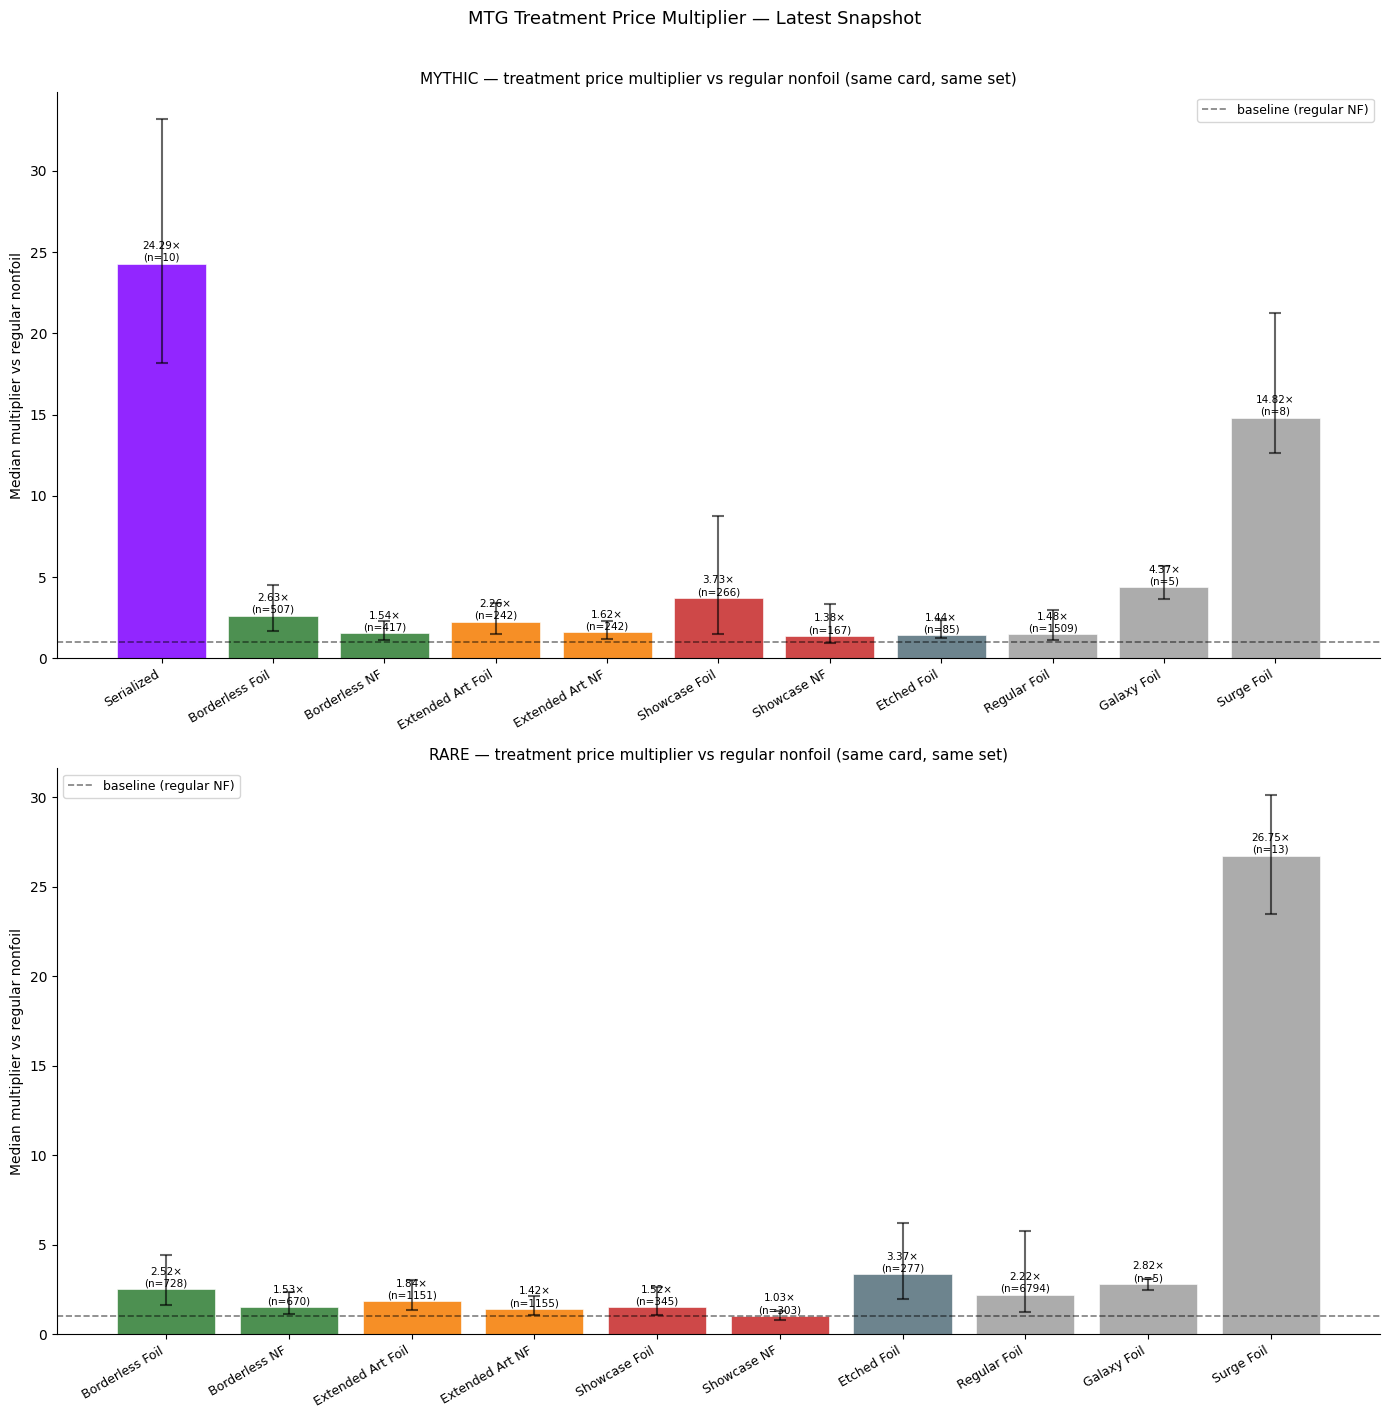

In [5]:
def get_treatment_label(tf):
    mapping = {
        'regular_foil':        'Regular Foil',
        'etched':              'Etched Foil',
        'showcase_nonfoil':    'Showcase NF',
        'showcase_foil':       'Showcase Foil',
        'extended_art_nonfoil':'Extended Art NF',
        'extended_art_foil':   'Extended Art Foil',
        'borderless_nonfoil':  'Borderless NF',
        'borderless_foil':     'Borderless Foil',
        'full_art_nonfoil':    'Full Art NF',
        'full_art_foil':       'Full Art Foil',
        'surge_foil':          'Surge Foil',
        'ripple_foil':         'Ripple Foil',
        'galaxy_foil':         'Galaxy Foil',
        'double_rainbow_foil': 'Double Rainbow',
        'serialized':          'Serialized',
    }
    return mapping.get(tf, tf.replace('_', ' ').title())

def treatment_color(tf):
    t = tf.replace('_foil','').replace('_nonfoil','')
    return TREATMENT_COLORS.get(t, '#9e9e9e')

def sort_key_tf(tf):
    t = tf.replace('_foil','').replace('_nonfoil','')
    idx = TREATMENT_ORDER.index(t) if t in TREATMENT_ORDER else 99
    foil_flag = 0 if tf.endswith('_foil') or t in ('serialized','double_rainbow_foil','galaxy_foil','surge_foil','ripple_foil','etched') else 1
    return (idx * 2 + foil_flag)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

for ax, rarity in zip(axes, RARITY_ORDER):
    sub = non_baseline[non_baseline['rarity_name'] == rarity].copy()
    
    # Filter to treatments with at least 5 data points
    counts = sub.groupby('treatment_finish').size()
    valid_tfs = counts[counts >= 5].index.tolist()
    sub = sub[sub['treatment_finish'].isin(valid_tfs)]
    
    order = sorted(valid_tfs, key=sort_key_tf)
    
    medians = sub.groupby('treatment_finish')['multiplier'].median()[order]
    p25     = sub.groupby('treatment_finish')['multiplier'].quantile(0.25)[order]
    p75     = sub.groupby('treatment_finish')['multiplier'].quantile(0.75)[order]
    ns      = sub.groupby('treatment_finish').size()[order]
    
    x = np.arange(len(order))
    colors = [treatment_color(tf) for tf in order]
    
    bars = ax.bar(x, medians.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.errorbar(x, medians.values,
                yerr=[medians.values - p25.values, p75.values - medians.values],
                fmt='none', color='black', linewidth=1.5, capsize=4, capthick=1.5, alpha=0.6)
    
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='baseline (regular NF)')
    
    for bar, med, n in zip(bars, medians.values, ns.values):
        ax.text(bar.get_x() + bar.get_width()/2, med + 0.05,
                f'{med:.2f}×\n(n={n})', ha='center', va='bottom', fontsize=7.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels([get_treatment_label(tf) for tf in order], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Median multiplier vs regular nonfoil', fontsize=10)
    ax.set_title(f'{rarity.upper()} — treatment price multiplier vs regular nonfoil (same card, same set)', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('MTG Treatment Price Multiplier — Latest Snapshot', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'treatment_fig1_multiplier_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3 — Distribution of Multipliers per Treatment

Bar charts show medians but hide spread. A violin plot reveals whether premiums are consistent  
or whether a treatment's median is driven by a few outlier cards.

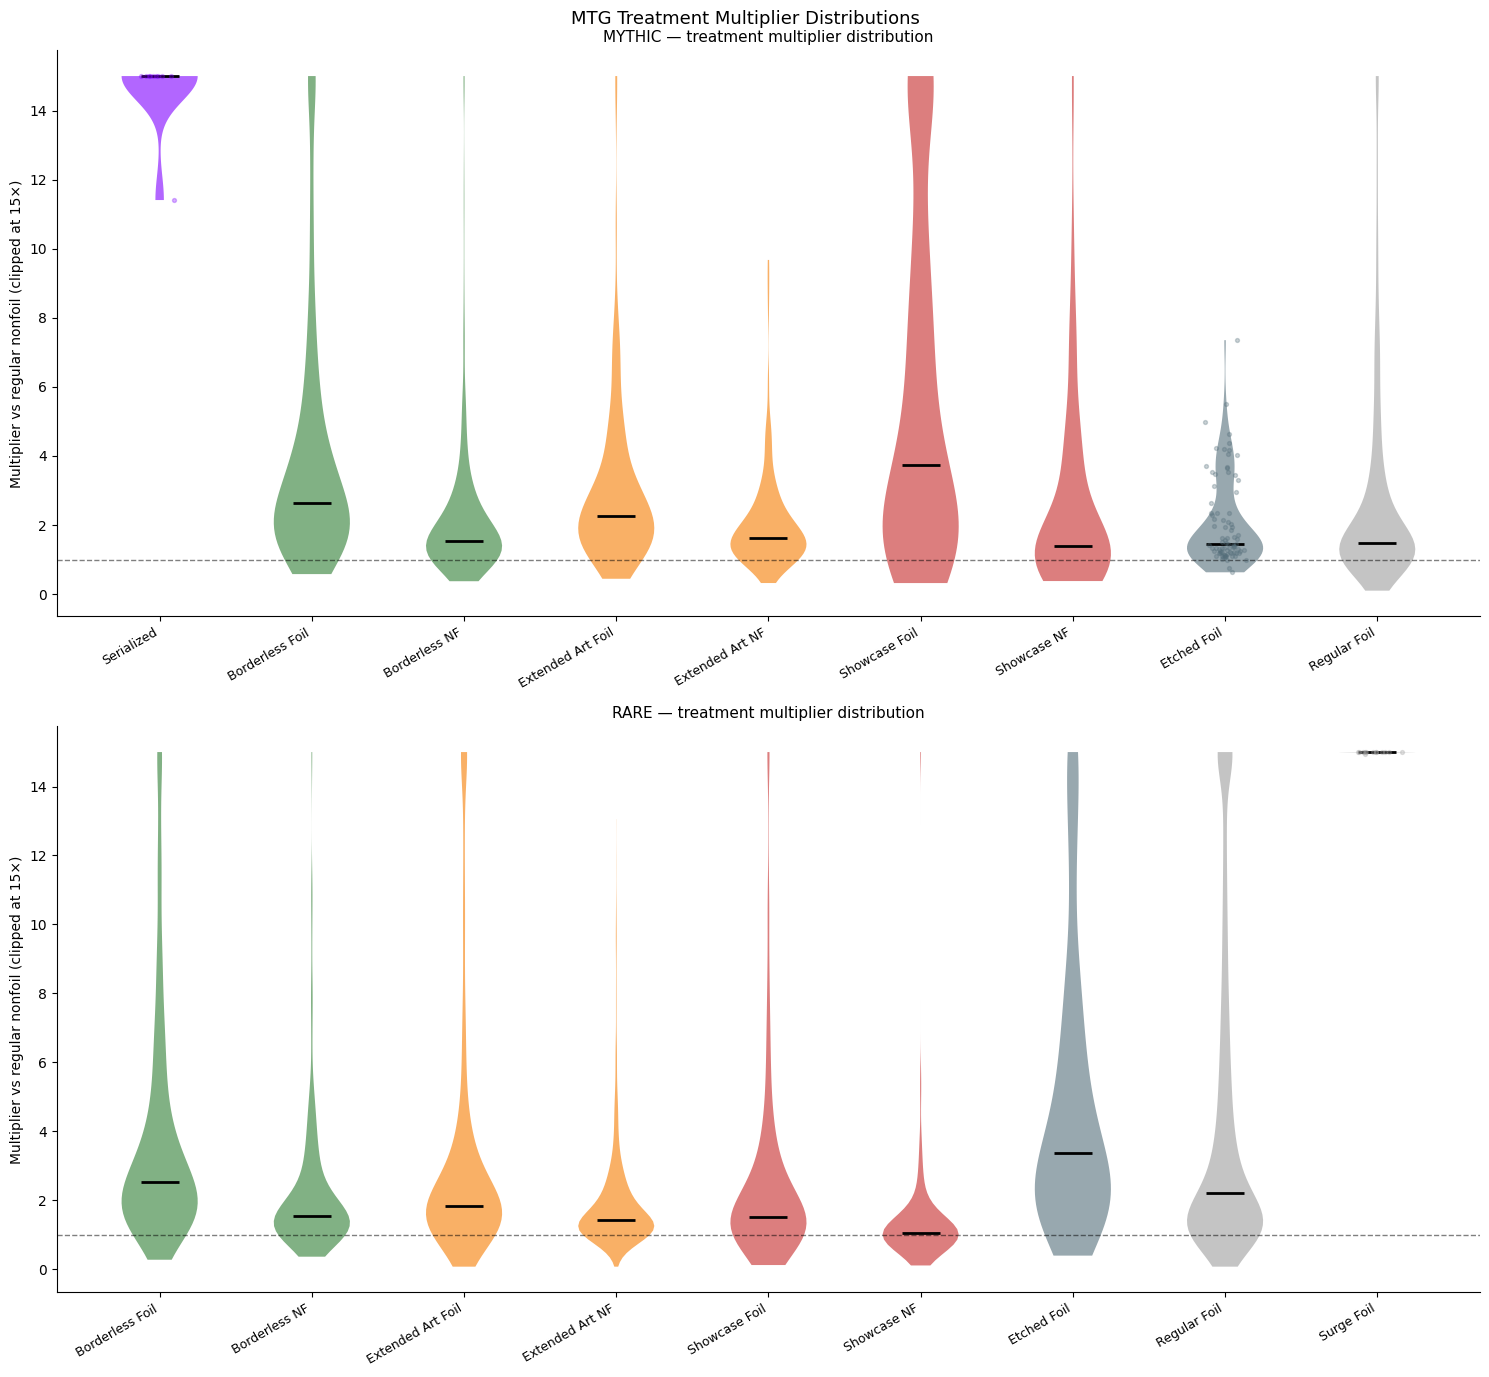

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

for ax, rarity in zip(axes, RARITY_ORDER):
    sub = non_baseline[non_baseline['rarity_name'] == rarity].copy()
    sub['mult_clipped'] = sub['multiplier'].clip(upper=15)
    
    counts = sub.groupby('treatment_finish').size()
    valid_tfs = counts[counts >= 10].index.tolist()
    sub = sub[sub['treatment_finish'].isin(valid_tfs)]
    order = sorted(valid_tfs, key=sort_key_tf)
    
    data_groups = [sub[sub['treatment_finish'] == tf]['mult_clipped'].values for tf in order]
    
    parts = ax.violinplot(data_groups, positions=range(len(order)),
                         showmedians=True, showextrema=False)
    
    for i, (pc, tf) in enumerate(zip(parts['bodies'], order)):
        pc.set_facecolor(treatment_color(tf))
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    
    # Overlay scatter (jittered) for small groups
    for i, (tf, grp) in enumerate(zip(order, data_groups)):
        if len(grp) < 100:
            jitter = np.random.normal(0, 0.06, size=len(grp))
            ax.scatter(i + jitter, grp, s=8, alpha=0.3,
                       color=treatment_color(tf), zorder=3)
    
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([get_treatment_label(tf) for tf in order], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Multiplier vs regular nonfoil (clipped at 15×)', fontsize=10)
    ax.set_title(f'{rarity.upper()} — treatment multiplier distribution', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('MTG Treatment Multiplier Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'treatment_fig2_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4 — Foil vs Nonfoil Gap Within Each Treatment

For every treatment that exists in both foil and nonfoil variants, what is the median  
additional premium of the foil version over the nonfoil version of the same treatment?

This answers: *after you've paid for the treatment, how much extra does foiling add?*

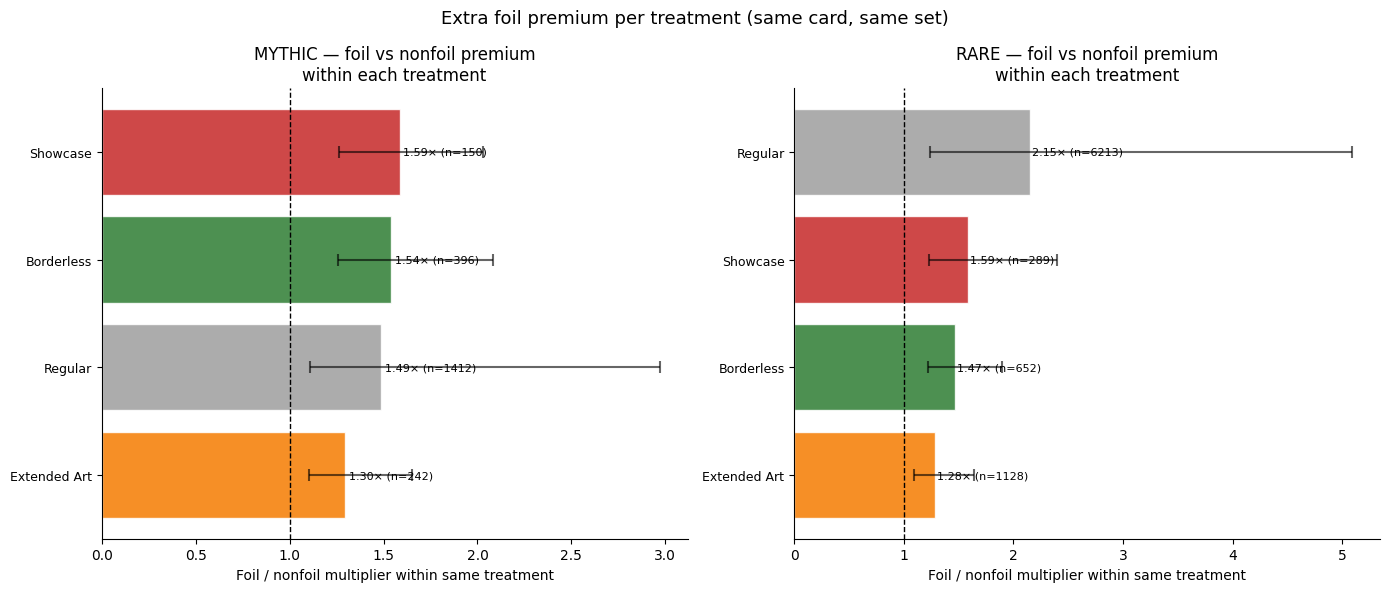


Foil vs nonfoil within treatment:


,treatment,rarity,n_cards,median_foil_over_nf,p25,p75,nf_median_mult,fo_median_mult
1,showcase,mythic,150,1.59,1.26,2.03,1.32,2.54
3,borderless,mythic,396,1.54,1.26,2.08,1.49,2.56
0,regular,mythic,1412,1.49,1.11,2.97,1.00,1.50
2,extended_art,mythic,242,1.30,1.10,1.65,1.62,2.26
4,regular,rare,6213,2.15,1.24,5.09,1.00,2.15
5,showcase,rare,289,1.59,1.23,2.39,1.03,1.61
7,borderless,rare,652,1.47,1.22,1.89,1.51,2.58
6,extended_art,rare,1128,1.28,1.10,1.64,1.43,1.86


In [7]:
# Build per-card foil/nonfoil multipliers for each treatment
foilable = ['regular', 'showcase', 'extended_art', 'borderless', 'full_art']

foil_gap_rows = []
for rarity in RARITY_ORDER:
    sub = mdf[mdf['rarity_name'] == rarity]
    for treatment in foilable:
        nf_sub = sub[(sub['treatment'] == treatment) & (sub['finish_code'] == 'NONFOIL')]
        fo_sub = sub[(sub['treatment'] == treatment) & (sub['finish_code'] == 'FOIL')]
        if nf_sub.empty or fo_sub.empty:
            continue
        nf_meds = nf_sub.groupby(['unique_card_id', 'set_code'])['multiplier'].median().rename('nf_mult')
        fo_meds = fo_sub.groupby(['unique_card_id', 'set_code'])['multiplier'].median().rename('fo_mult')
        both = nf_meds.to_frame().join(fo_meds, how='inner').reset_index()
        if len(both) < 3:
            continue
        both['foil_over_nf'] = both['fo_mult'] / both['nf_mult']
        both = both[both['foil_over_nf'].between(0.1, 20)]
        foil_gap_rows.append({
            'treatment': treatment,
            'rarity': rarity,
            'n_cards': len(both),
            'median_foil_over_nf': both['foil_over_nf'].median(),
            'p25': both['foil_over_nf'].quantile(0.25),
            'p75': both['foil_over_nf'].quantile(0.75),
            'nf_median_mult': both['nf_mult'].median(),
            'fo_median_mult': both['fo_mult'].median(),
        })

gap_df = pd.DataFrame(foil_gap_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = gap_df[gap_df['rarity'] == rarity].sort_values('median_foil_over_nf', ascending=True)
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center')
        continue
    y = np.arange(len(sub))
    colors = [TREATMENT_COLORS.get(t, '#9e9e9e') for t in sub['treatment']]
    bars = ax.barh(y, sub['median_foil_over_nf'].values, color=colors, alpha=0.85, edgecolor='white')
    ax.errorbar(sub['median_foil_over_nf'].values, y,
                xerr=[sub['median_foil_over_nf'].values - sub['p25'].values,
                      sub['p75'].values - sub['median_foil_over_nf'].values],
                fmt='none', color='black', linewidth=1.5, capsize=4, capthick=1.5, alpha=0.6)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels([t.replace('_', ' ').title() for t in sub['treatment']], fontsize=9)
    for bar, val, n in zip(bars, sub['median_foil_over_nf'].values, sub['n_cards'].values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}× (n={n})', va='center', fontsize=8)
    ax.set_xlabel('Foil / nonfoil multiplier within same treatment')
    ax.set_title(f'{rarity.upper()} — foil vs nonfoil premium\nwithin each treatment')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Extra foil premium per treatment (same card, same set)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'treatment_fig3_foil_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFoil vs nonfoil within treatment:')
display(gap_df.sort_values(['rarity', 'median_foil_over_nf'], ascending=[True, False]).round(2))

## Part 5 — Treatment Multiplier Over Time

Using `print_price_daily` to track how treatment premiums evolve after a set releases.

We focus on Modern Horizons 2 (MH2) and one recent expansion as comparison points.  
The key question: do treatment premiums hold, expand, or compress over the first 2 years?

In [8]:
FOCUS_SETS = ['mh2', 'dmu', 'mom', 'woe', 'ltr', 'mh3']
FOCUS_SET_NAMES = {
    'mh2': 'MH2 (Jun 2021)',
    'dmu': 'DMU (Sep 2022)',
    'mom': 'MOM (Apr 2023)',
    'woe': 'WOE (Sep 2023)',
    'ltr': 'LTR (Jun 2023)',
    'mh3': 'MH3 (Jun 2024)',
}

SQL_TIMESERIES = """
WITH promo_agg AS (
    SELECT pc.card_version_id, array_agg(pt.promo_type_desc) AS promo_types
    FROM card_catalog.promo_card pc
    JOIN card_catalog.promo_types_ref pt ON pt.promo_id = pc.promo_id
    GROUP BY pc.card_version_id
)
SELECT
    ppd.price_date,
    s.set_code,
    cv.unique_card_id::text,
    r.rarity_name,
    cf.code AS finish_code,
    CASE
        WHEN pa.promo_types && ARRAY['serialized']      THEN 'serialized'
        WHEN pa.promo_types && ARRAY['doublerainbow']   THEN 'double_rainbow_foil'
        WHEN pa.promo_types && ARRAY['galaxyfoil']      THEN 'galaxy_foil'
        WHEN pa.promo_types && ARRAY['surgefoil']       THEN 'surge_foil'
        WHEN pa.promo_types && ARRAY['ripplefoil']      THEN 'ripple_foil'
        WHEN bc.border_color_name = 'borderless'        THEN 'borderless'
        WHEN 'extendedart' = ANY(cv.frame_effects)      THEN 'extended_art'
        WHEN 'showcase'    = ANY(cv.frame_effects)      THEN 'showcase'
        WHEN 'fullart'     = ANY(cv.frame_effects)      THEN 'full_art'
        WHEN cf.code = 'ETCHED'                         THEN 'etched'
        ELSE 'regular'
    END AS treatment,
    AVG(ppd.list_avg_cents) AS price_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.card_finished cf      ON cf.finish_id = ppd.finish_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
LEFT JOIN card_catalog.border_color_ref bc ON bc.border_color_id = cv.border_color_id
LEFT JOIN promo_agg pa                  ON pa.card_version_id = cv.card_version_id
JOIN pricing.price_source ps            ON ps.source_id = ppd.source_id
JOIN pricing.transaction_type tt        ON tt.transaction_type_id = ppd.transaction_type_id
JOIN pricing.card_condition cc          ON cc.condition_id = ppd.condition_id
JOIN card_catalog.language_ref lr       ON lr.language_id = ppd.language_id
WHERE s.set_code = ANY(%(sets)s)
  AND r.rarity_name IN ('mythic', 'rare')
  AND NOT cv.is_digital
  AND ps.code IN ('tcg', 'mtgstocks')
  AND tt.transaction_type_code = 'sell'
  AND cc.code = 'NM'
  AND lr.language_code = 'en'
  AND ppd.list_avg_cents IS NOT NULL
  AND ppd.list_avg_cents > 0
GROUP BY ppd.price_date, s.set_code, cv.unique_card_id, r.rarity_name, cf.code,
         pa.promo_types, bc.border_color_name, cv.frame_effects
"""

PARQUET_TS = DATA_DIR / 'treatment_timeseries.parquet'
if REFRESH or not PARQUET_TS.exists():
    print('Loading time-series data...')
    ts_raw = query_to_df(SQL_TIMESERIES, {'sets': FOCUS_SETS})
    ts_raw['price_date'] = pd.to_datetime(ts_raw['price_date'])
    ts_raw['price_cents'] = pd.to_numeric(ts_raw['price_cents'])
    ts_raw.to_parquet(PARQUET_TS, index=False)
    print(f'  Saved {len(ts_raw):,} rows')
else:
    ts_raw = pd.read_parquet(PARQUET_TS)
    print(f'Loaded {len(ts_raw):,} time-series rows')

ts_raw.head(3)

Loading time-series data...
  Saved 3,106,849 rows


,price_date,set_code,unique_card_id,rarity_name,finish_code,treatment,price_cents
0,2021-05-17,mh2,0385b99f-fcc0-4987-9507-999a53baa9f6,rare,FOIL,extended_art,24949.0
1,2021-05-17,mh2,0385b99f-fcc0-4987-9507-999a53baa9f6,rare,FOIL,regular,8000.0
2,2021-05-17,mh2,0385b99f-fcc0-4987-9507-999a53baa9f6,rare,NONFOIL,extended_art,14949.0


In [9]:
# Add treatment_finish and compute per-card daily multipliers
ts_raw['treatment_finish'] = ts_raw.apply(
    lambda row: row['treatment'] if row['treatment'] in
        ('serialized','double_rainbow_foil','galaxy_foil','surge_foil','ripple_foil','etched')
    else (f"{row['treatment']}_foil" if row['finish_code'] == 'FOIL' else f"{row['treatment']}_nonfoil"),
    axis=1
)

# Baseline: regular nonfoil per card × set × date
ts_baseline = (
    ts_raw[(ts_raw['treatment'] == 'regular') & (ts_raw['finish_code'] == 'NONFOIL')]
    .groupby(['price_date', 'set_code', 'unique_card_id'])['price_cents']
    .median().reset_index().rename(columns={'price_cents': 'baseline_cents'})
)

ts = ts_raw.merge(ts_baseline, on=['price_date', 'set_code', 'unique_card_id'], how='inner')
ts = ts[ts['baseline_cents'] > 0].copy()
ts['multiplier'] = ts['price_cents'] / ts['baseline_cents']
ts = ts[ts['multiplier'].between(0.1, 30)]

# Monthly median multiplier by treatment_finish × rarity × set
ts['month'] = ts['price_date'].dt.to_period('M')
ts_monthly = (
    ts[ts['treatment'] != 'regular']
    .groupby(['month', 'set_code', 'rarity_name', 'treatment_finish'])['multiplier']
    .agg(median='median', n='count')
    .reset_index()
)
ts_monthly['month_dt'] = ts_monthly['month'].dt.to_timestamp()

print(f'Monthly rows: {len(ts_monthly):,}')
ts_monthly.head(3)

Monthly rows: 2,955


,month,set_code,rarity_name,treatment_finish,median,n,month_dt
0,2021-05,mh2,mythic,borderless_foil,2.862921,65,2021-05-01
1,2021-05,mh2,mythic,borderless_nonfoil,1.433966,70,2021-05-01
2,2021-05,mh2,mythic,etched,1.972870,24,2021-05-01


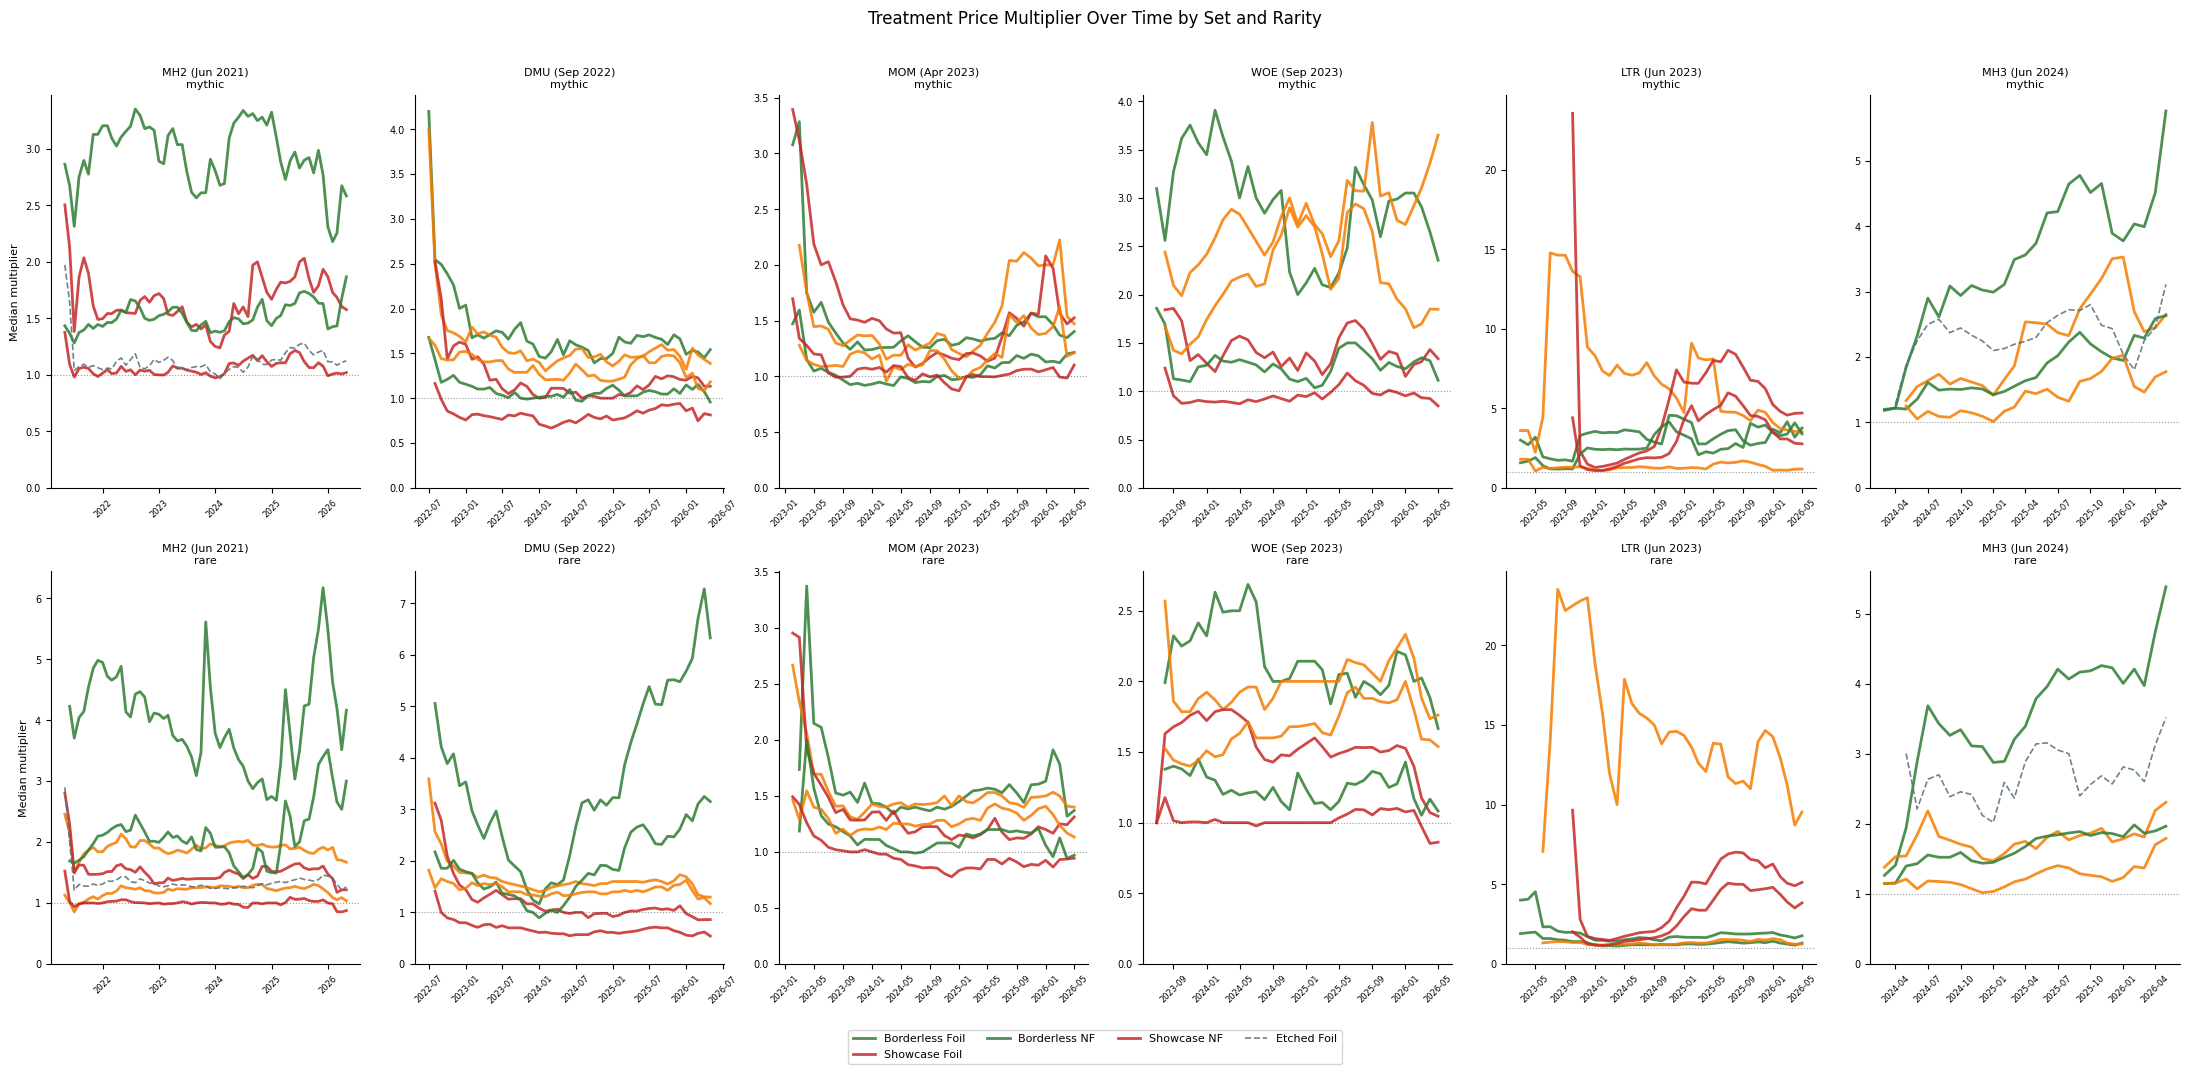

In [10]:
# Show treatment premium evolution for MH2 (best data, most treatments)
PLOT_TREATMENTS = ['borderless_foil', 'extended_art_foil', 'showcase_foil',
                   'borderless_nonfoil', 'extended_art_nonfoil', 'showcase_nonfoil',
                   'regular_foil', 'etched']

fig, axes = plt.subplots(len(RARITY_ORDER), len(FOCUS_SETS), figsize=(22, 10), squeeze=False)

for row, rarity in enumerate(RARITY_ORDER):
    for col, set_code in enumerate(FOCUS_SETS):
        ax = axes[row, col]
        sub = ts_monthly[
            (ts_monthly['rarity_name'] == rarity) &
            (ts_monthly['set_code'] == set_code) &
            (ts_monthly['n'] >= 3)
        ]
        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', fontsize=9, transform=ax.transAxes)
            ax.set_title(f'{FOCUS_SET_NAMES.get(set_code, set_code)}\n{rarity}', fontsize=8)
            continue
        
        for tf in PLOT_TREATMENTS:
            tf_sub = sub[sub['treatment_finish'] == tf].sort_values('month_dt')
            if len(tf_sub) < 2:
                continue
            lw = 2.0 if 'foil' in tf else 1.2
            ls = '-' if 'foil' in tf else '--'
            ax.plot(tf_sub['month_dt'], tf_sub['median'],
                    color=treatment_color(tf), linewidth=lw, linestyle=ls,
                    label=get_treatment_label(tf), alpha=0.85)
        
        ax.axhline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
        ax.set_title(f'{FOCUS_SET_NAMES.get(set_code, set_code)}\n{rarity}', fontsize=8)
        ax.set_ylim(bottom=0)
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if col == 0:
            ax.set_ylabel('Median multiplier', fontsize=8)

# Single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
if not handles:
    for ax_row in axes:
        for ax in ax_row:
            h, l = ax.get_legend_handles_labels()
            if h:
                handles, labels = h, l
                break
        if handles:
            break

if handles:
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Treatment Price Multiplier Over Time by Set and Rarity', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'treatment_fig4_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 6 — Reprint Resilience: How Reprints Affect Treatment Premiums

When a card is reprinted, does the treatment premium hold relative to the new regular nonfoil?  
We find cards reprinted 2+ times and compare treatment premiums across print runs.

In [11]:
# Cards with 3+ total print runs (any treatment) — good candidates for reprint study
print_counts = (
    priced.groupby(['unique_card_id', 'card_name'])['set_code']
    .nunique().reset_index()
    .rename(columns={'set_code': 'n_sets'})
    .sort_values('n_sets', ascending=False)
)

multi_print_cards = print_counts[print_counts['n_sets'] >= 4]
print(f'Cards with 4+ set appearances: {len(multi_print_cards):,}')

# For top 20 reprinted mythics/rares: show treatment × set price matrix
top_reprinted = (
    priced[priced['rarity_name'].isin(['mythic', 'rare'])]
    .merge(multi_print_cards[['unique_card_id']].head(20), on='unique_card_id')
)

# Pivot: card × set → treatment premium
reprint_pivot = (
    top_reprinted.groupby(['card_name', 'set_code', 'treatment_finish'])['price_usd']
    .median().reset_index()
    .pivot_table(index=['card_name', 'set_code'], columns='treatment_finish', values='price_usd')
    .reset_index()
)

if 'regular_nonfoil' in reprint_pivot.columns:
    print('\nSample: regular nonfoil price across printings (top reprinted mythics/rares):')
    sample = reprint_pivot[reprint_pivot['regular_nonfoil'].notna()][['card_name', 'set_code', 'regular_nonfoil']]
    display(sample.sort_values(['card_name', 'set_code']).head(30))

Cards with 4+ set appearances: 127

Sample: regular nonfoil price across printings (top reprinted mythics/rares):


treatment_finish,card_name,set_code,regular_nonfoil
0,Balefire Dragon,cmm,17.25
1,Balefire Dragon,inr,14.29
2,Balefire Dragon,isd,15.16
3,Balefire Dragon,plst,16.63
4,Balefire Dragon,uma,17.20
5,Blood Crypt,dis,20.62
6,Blood Crypt,ecl,9.93
7,Blood Crypt,plst,24.08
8,Blood Crypt,rna,10.02
9,Blood Crypt,rtr,9.64


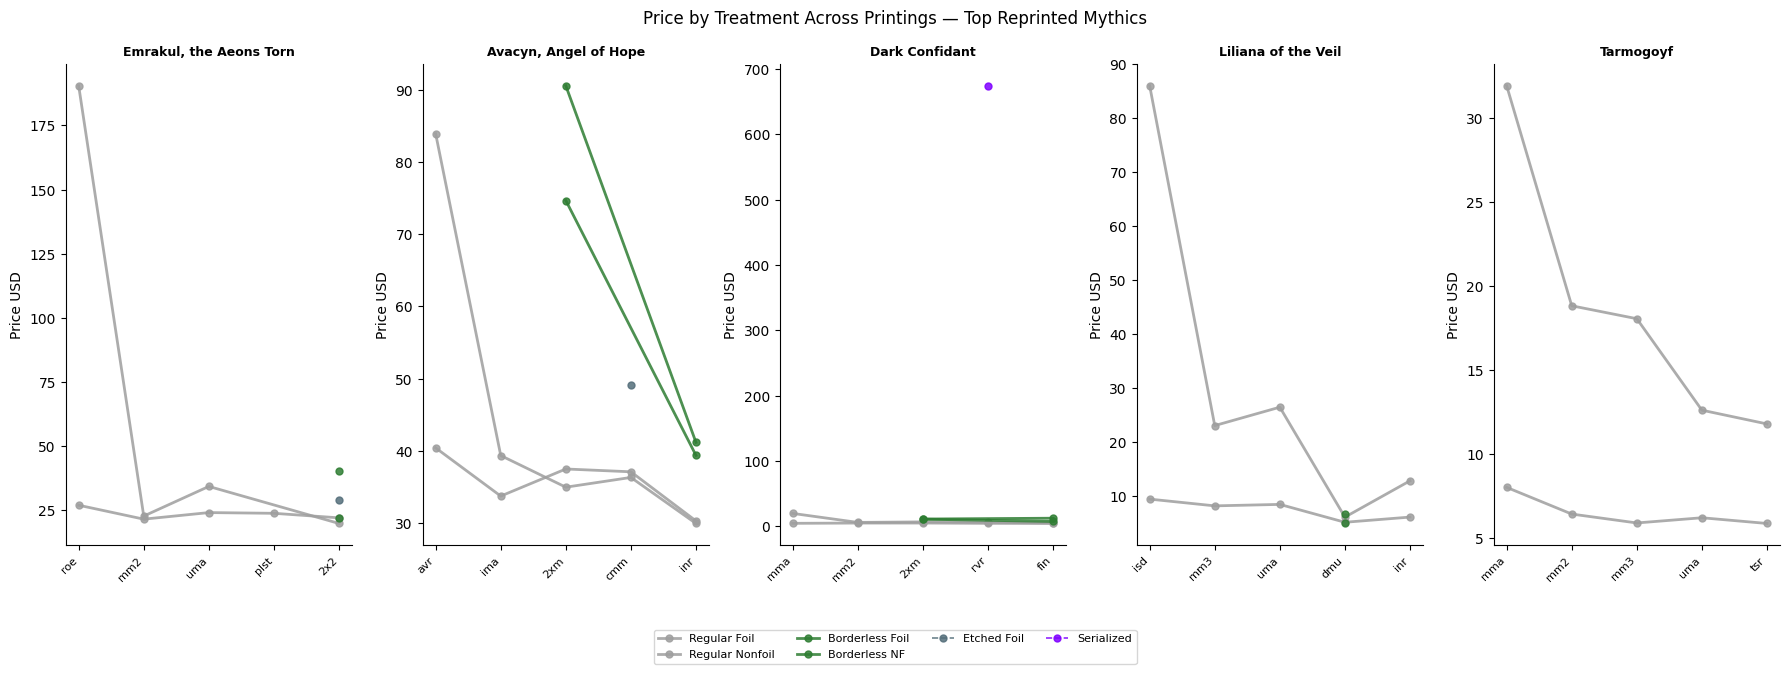

In [12]:
# Pick the top 5 most-reprinted mythics for the visualisation
top_mythics = (
    priced[priced['rarity_name'] == 'mythic']
    .groupby(['unique_card_id', 'card_name'])['set_code'].nunique()
    .reset_index()
    .sort_values('set_code', ascending=False)
    .head(5)
)

fig, axes = plt.subplots(1, len(top_mythics), figsize=(18, 6), sharey=False)
if len(top_mythics) == 1:
    axes = [axes]

for ax, (_, row_) in zip(axes, top_mythics.iterrows()):
    card_data = priced[
        (priced['unique_card_id'] == row_['unique_card_id']) &
        (priced['rarity_name'] == 'mythic')
    ].sort_values('released_at')
    
    if card_data.empty:
        continue
    
    # Group by set × treatment_finish, take median price
    card_pivot = (
        card_data.groupby(['set_code', 'released_at', 'treatment_finish'])['price_usd']
        .median().reset_index()
        .sort_values('released_at')
    )
    
    set_order = card_pivot.drop_duplicates('set_code').sort_values('released_at')['set_code'].tolist()
    
    for tf in card_pivot['treatment_finish'].unique():
        tf_data = card_pivot[card_pivot['treatment_finish'] == tf]
        x = [set_order.index(sc) for sc in tf_data['set_code']]
        lw = 2.0 if 'foil' in str(tf) else 1.2
        ls = '-' if 'foil' in str(tf) else '--'
        ax.plot(x, tf_data['price_usd'].values,
                marker='o', markersize=5, linewidth=lw, linestyle=ls,
                color=treatment_color(tf), label=get_treatment_label(tf), alpha=0.85)
    
    ax.set_xticks(range(len(set_order)))
    ax.set_xticklabels(set_order, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Price USD')
    ax.set_title(row_['card_name'], fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle); labels.append(label)

if handles:
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.12))

fig.suptitle('Price by Treatment Across Printings — Top Reprinted Mythics', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'treatment_fig5_reprint_resilience.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 7 — Set-Level Breakdown: Which Treatment Won?

For each set, the highest-median-multiplier treatment for mythics and rares.  
This shows whether the "winner" is consistent across sets or set-specific.

In [13]:
set_winners = (
    non_baseline
    [non_baseline['treatment'] != 'regular']  # exclude regular foil from 'winner' context
    .groupby(['set_code', 'set_name', 'released_at', 'rarity_name', 'treatment_finish'])['multiplier']
    .agg(median='median', n='count')
    .reset_index()
)

# Keep only treatments with enough data points per set (n >= 3)
set_winners = set_winners[set_winners['n'] >= 3]

# Best treatment per set × rarity
best_per_set = (
    set_winners.sort_values('median', ascending=False)
    .drop_duplicates(['set_code', 'rarity_name'])
    .sort_values(['rarity_name', 'released_at'])
)

for rarity in RARITY_ORDER:
    sub = best_per_set[best_per_set['rarity_name'] == rarity][['set_code','set_name','released_at','treatment_finish','median','n']]
    sub = sub.rename(columns={'treatment_finish': 'winning_treatment', 'median': 'mult_vs_reg_nf'})
    sub = sub.sort_values('released_at')
    print(f'\n═══ {rarity.upper()} — Highest-Multiplier Treatment per Set ═══')
    display(sub.round(2).to_string(index=False))


═══ MYTHIC — Highest-Multiplier Treatment per Set ═══


"set_code                            set_name released_at winning_treatment  mult_vs_reg_nf  n\n     eld                  Throne of Eldraine  2019-10-04 extended_art_foil            4.97 10\n     thb                 Theros Beyond Death  2020-01-24 extended_art_foil            6.40  5\n     iko           Ikoria: Lair of Behemoths  2020-04-24   borderless_foil            6.36 13\n     2xm                      Double Masters  2020-08-07   borderless_foil            2.07 20\n     znr                     Zendikar Rising  2020-09-25 extended_art_foil            2.07 15\n     khm                            Kaldheim  2021-02-05 extended_art_foil            1.88  4\n     stx         Strixhaven: School of Mages  2021-04-23   borderless_foil            3.93  9\n     afr  Adventures in the Forgotten Realms  2021-07-23   borderless_foil            2.51 11\n     mid            Innistrad: Midnight Hunt  2021-09-24 extended_art_foil            2.46 14\n     vow              Innistrad: Crimson Vow  202


═══ RARE — Highest-Multiplier Treatment per Set ═══


"set_code                            set_name released_at  winning_treatment  mult_vs_reg_nf   n\n     eld                  Throne of Eldraine  2019-10-04  extended_art_foil            9.77  47\n     thb                 Theros Beyond Death  2020-01-24  extended_art_foil            6.70  49\n     iko           Ikoria: Lair of Behemoths  2020-04-24  extended_art_foil            3.37  43\n     2xm                      Double Masters  2020-08-07 borderless_nonfoil            2.11  12\n     znr                     Zendikar Rising  2020-09-25      showcase_foil            1.76   7\n     khm                            Kaldheim  2021-02-05      showcase_foil            1.84  14\n     stx         Strixhaven: School of Mages  2021-04-23  extended_art_foil            2.10  70\n     afr  Adventures in the Forgotten Realms  2021-07-23  extended_art_foil            1.41  31\n     mid            Innistrad: Midnight Hunt  2021-09-24    borderless_foil            1.79   5\n     vow              Innistr

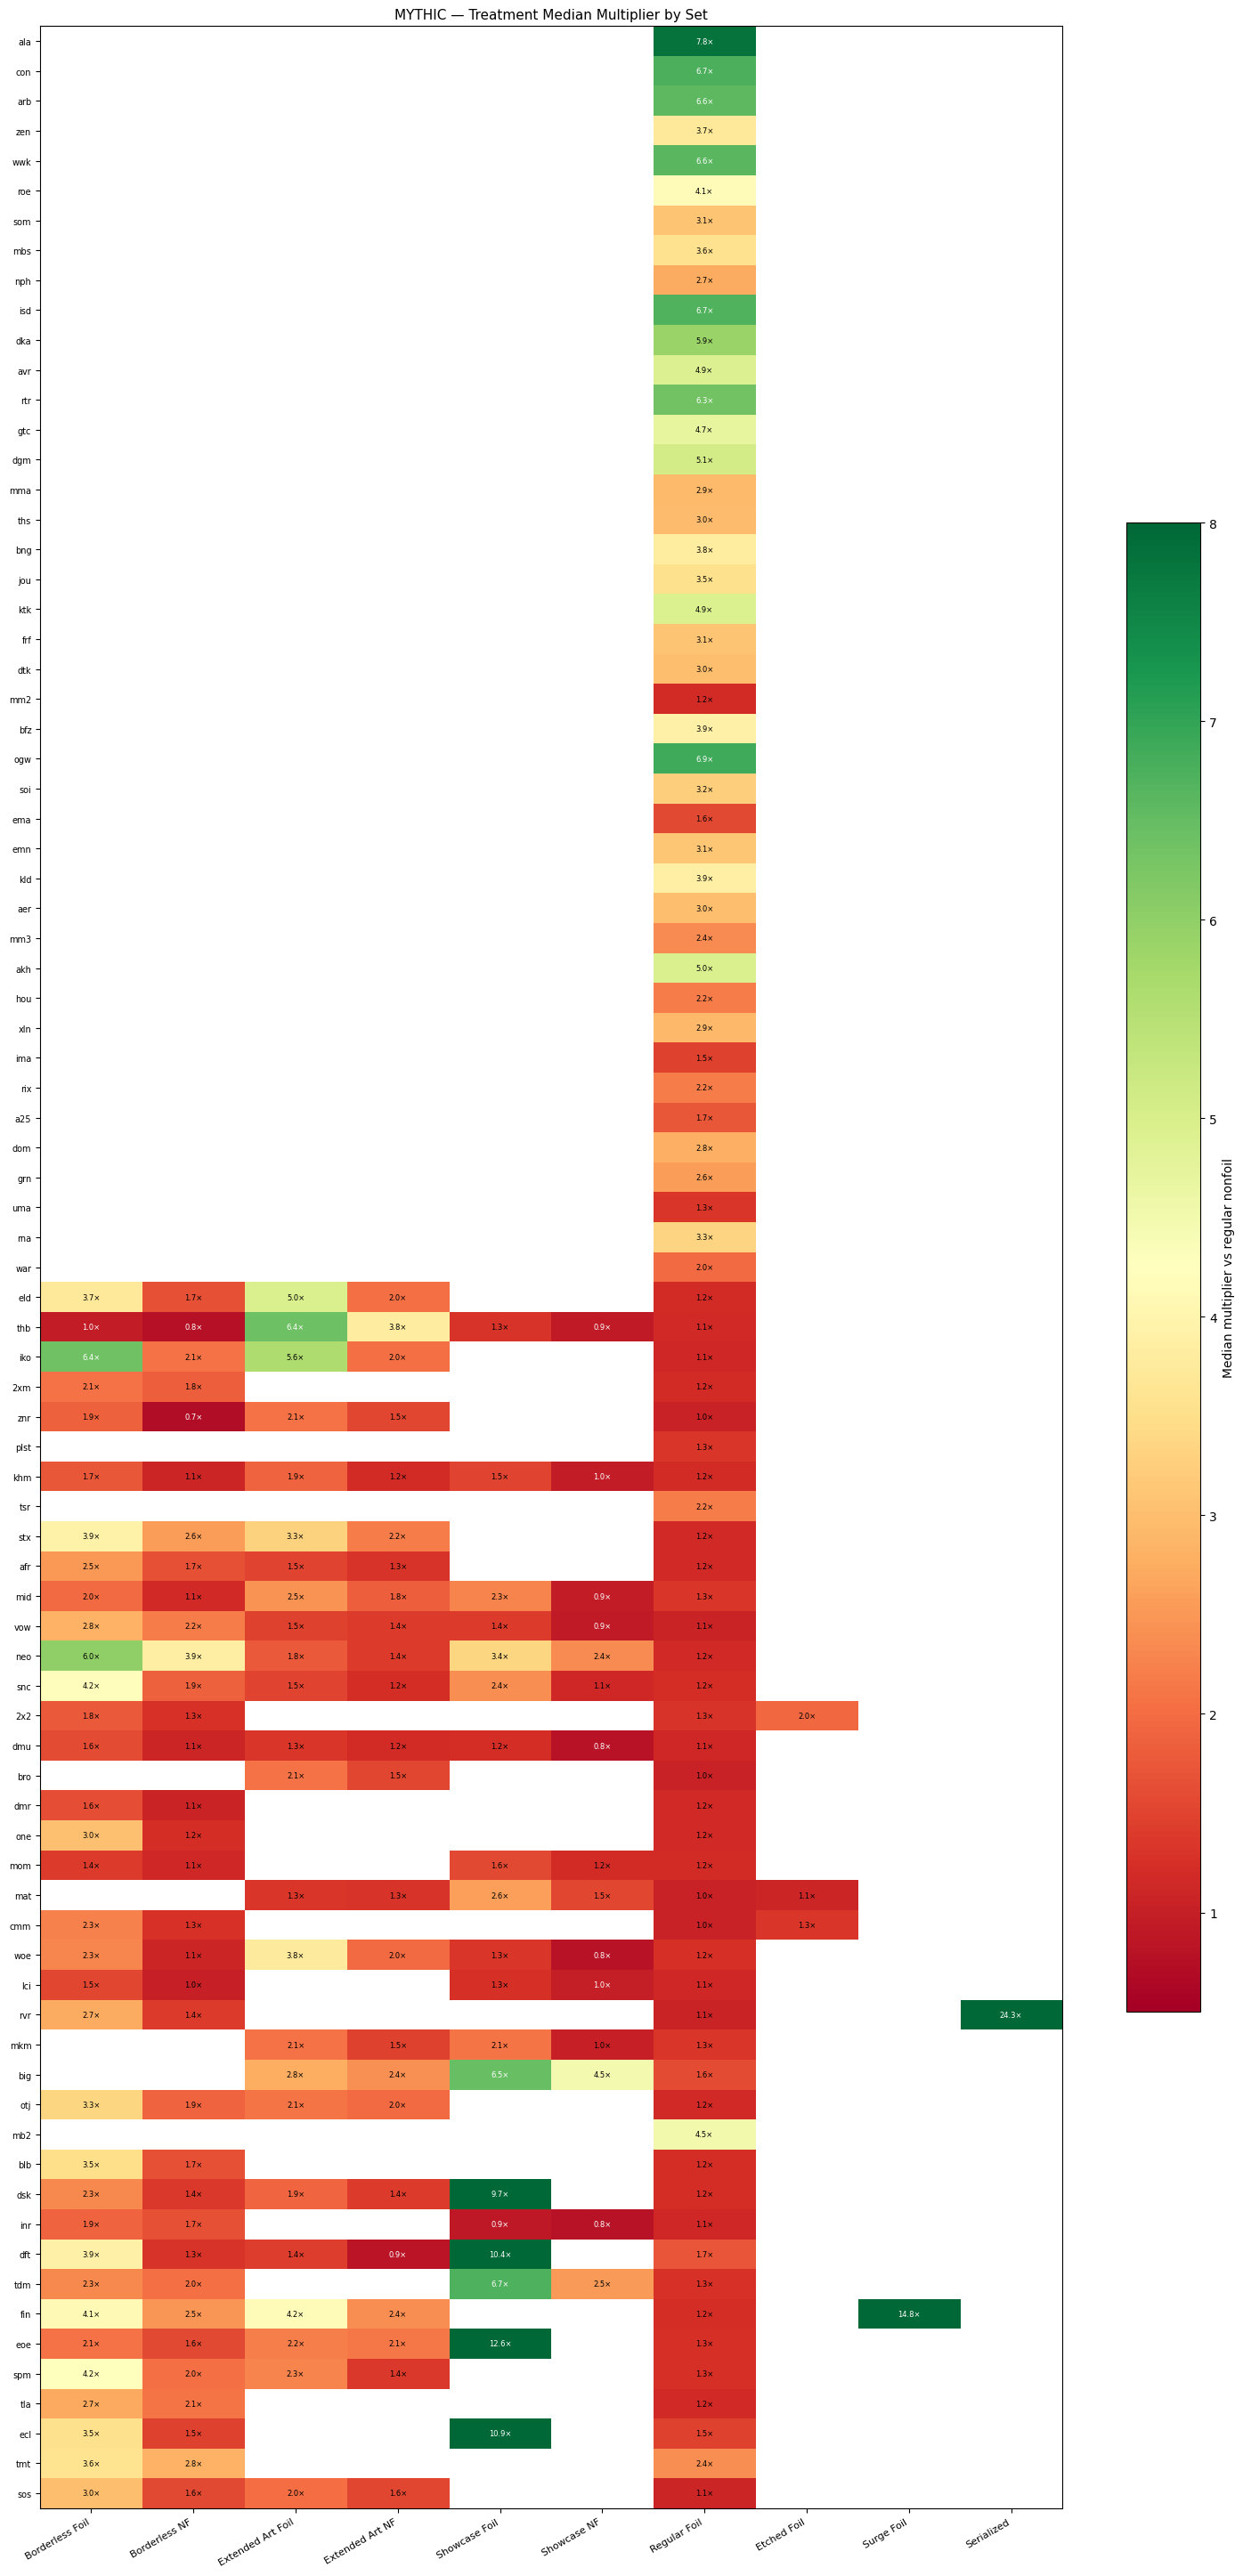

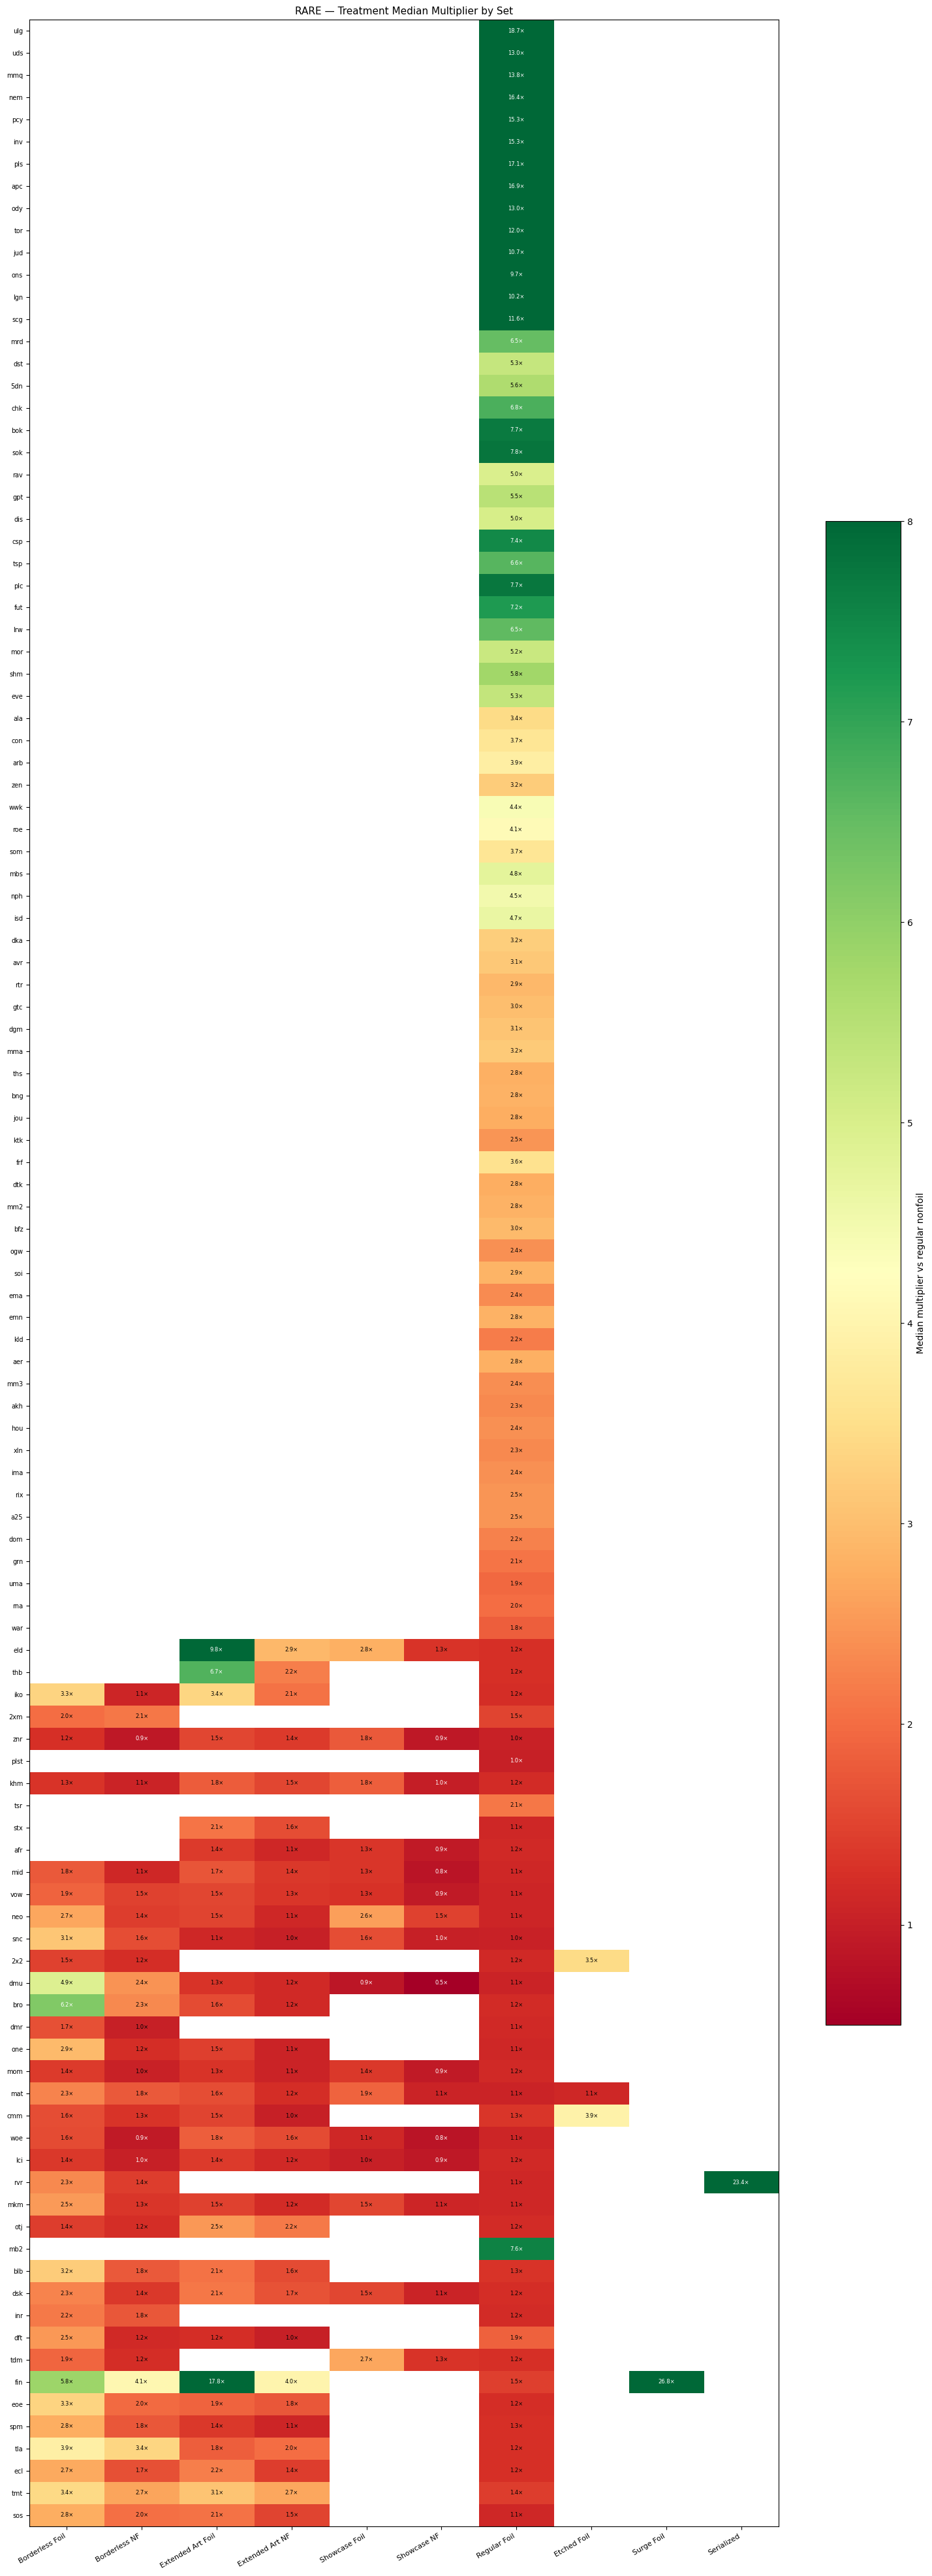

In [15]:
# Heatmap: treatment median multiplier per set (mythics only)
HEAT_TREATMENTS = ['borderless_foil', 'borderless_nonfoil',
                   'extended_art_foil', 'extended_art_nonfoil',
                   'showcase_foil', 'showcase_nonfoil',
                   'regular_foil', 'etched',
                   'surge_foil', 'serialized']

for rarity in RARITY_ORDER:
    heat_data = (
        non_baseline[
            (non_baseline['rarity_name'] == rarity) &
            (non_baseline['treatment_finish'].isin(HEAT_TREATMENTS))
        ]
        .groupby(['set_code', 'treatment_finish'])['multiplier']
        .agg(median='median', n='count')
        .reset_index()
    )
    heat_data = heat_data[heat_data['n'] >= 3]

    # Join released_at for set ordering
    set_dates = versions[['set_code', 'released_at']].drop_duplicates().set_index('set_code')['released_at']
    heat_pivot = heat_data.pivot(index='set_code', columns='treatment_finish', values='median')
    heat_pivot = heat_pivot.loc[
        heat_pivot.index.intersection(set_dates.index)
    ].sort_index(key=lambda idx: idx.map(set_dates))
    heat_pivot = heat_pivot[[c for c in HEAT_TREATMENTS if c in heat_pivot.columns]]
    
    if heat_pivot.empty:
        print(f'No heatmap data for {rarity}')
        continue
    
    fig, ax = plt.subplots(figsize=(max(10, len(heat_pivot.columns) * 1.5),
                                    max(6, len(heat_pivot) * 0.35)))
    im = ax.imshow(heat_pivot.values.astype(float), aspect='auto',
                   cmap='RdYlGn', vmin=0.5, vmax=8)
    
    plt.colorbar(im, ax=ax, label='Median multiplier vs regular nonfoil', shrink=0.6)
    ax.set_xticks(range(len(heat_pivot.columns)))
    ax.set_xticklabels([get_treatment_label(c) for c in heat_pivot.columns],
                       rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(heat_pivot)))
    ax.set_yticklabels(heat_pivot.index, fontsize=7)
    
    # Annotate cells
    for i in range(len(heat_pivot)):
        for j in range(len(heat_pivot.columns)):
            val = heat_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}×', ha='center', va='center',
                        fontsize=6, color='black' if 1 < val < 6 else 'white')
    
    ax.set_title(f'{rarity.upper()} — Treatment Median Multiplier by Set', fontsize=11)
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'treatment_fig6_heatmap_{rarity}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Part 8 — Conclusions

Synthesise findings from the data.

In [16]:
print('=== TREATMENT PRICE ANALYSIS — FINDINGS ===')
print()

# 1. Overall median multiplier ranking
overall_ranking = (
    non_baseline.groupby(['treatment_finish', 'rarity_name'])['multiplier']
    .agg(median='median', n='count')
    .reset_index()
)

for rarity in RARITY_ORDER:
    sub = overall_ranking[
        (overall_ranking['rarity_name'] == rarity) &
        (overall_ranking['n'] >= 5)
    ].sort_values('median', ascending=False)
    
    print(f'--- {rarity.upper()} — Treatment Ranking by Median Multiplier ---')
    for _, row_ in sub.iterrows():
        bar = '█' * int(row_['median'] * 3)
        print(f'  {row_["treatment_finish"]:30s}  {row_["median"]:5.2f}×  {bar}  (n={int(row_["n"]):,})')
    print()

# 2. Winner consistency across sets
print('--- Most Consistent Top Treatment per Set ---')
winner_counts = (
    best_per_set.groupby(['rarity_name', 'treatment_finish']).size()
    .reset_index(name='sets_won')
    .sort_values(['rarity_name', 'sets_won'], ascending=[True, False])
)
for rarity in RARITY_ORDER:
    sub = winner_counts[winner_counts['rarity_name'] == rarity].head(5)
    print(f'  {rarity.upper()}:')
    for _, r in sub.iterrows():
        print(f'    {r["treatment_finish"]:30s}  won {int(r["sets_won"])} sets')
print()

# 3. Foil vs nonfoil within treatment summary
if not gap_df.empty:
    print('--- Foil Premium Within Treatment (median foil / nonfoil same treatment, same card) ---')
    for rarity in RARITY_ORDER:
        sub = gap_df[gap_df['rarity'] == rarity].sort_values('median_foil_over_nf', ascending=False)
        print(f'  {rarity.upper()}:')
        for _, r in sub.iterrows():
            print(f'    {r["treatment"]:20s}  foil adds {r["median_foil_over_nf"]:.2f}×  (n={int(r["n_cards"])} cards)')

=== TREATMENT PRICE ANALYSIS — FINDINGS ===

--- MYTHIC — Treatment Ranking by Median Multiplier ---
  serialized                      24.29×  ████████████████████████████████████████████████████████████████████████  (n=10)
  surge_foil                      14.82×  ████████████████████████████████████████████  (n=8)
  galaxy_foil                      4.37×  █████████████  (n=5)
  showcase_foil                    3.73×  ███████████  (n=266)
  borderless_foil                  2.63×  ███████  (n=507)
  extended_art_foil                2.26×  ██████  (n=242)
  extended_art_nonfoil             1.62×  ████  (n=242)
  borderless_nonfoil               1.54×  ████  (n=417)
  regular_foil                     1.48×  ████  (n=1,509)
  etched                           1.44×  ████  (n=85)
  showcase_nonfoil                 1.38×  ████  (n=167)

--- RARE — Treatment Ranking by Median Multiplier ---
  surge_foil                      26.75×  █████████████████████████████████████████████████████████████